PASO 1: SELECCIÓN DE COLUMNAS NECESARIAS PARA LA ACTUALIZACIÓN 

In [ ]:
import pandas as pd
import polars as pl

# Filtramos las columnas que se estan empleando para la base de datos actual y las colocamos en un dataframe
df=pd.read_csv('DEFUN99.csv', usecols=['ent_resid','mun_resid','causa_def','lista_mex','sexo','edad','dia_ocurr','mes_ocurr','anio_ocur','ocupacion','escolarida','derechohab','lista1','gr_lismex'], encoding="utf-8")
df=df.rename(columns={'ent_resid':'ENT_RESID',
                      'mun_resid':'MUN_RESID',
                      'causa_def':'CAUSA_DEF',
                      'lista_mex':'LISTA_MEX',
                      'sexo':'SEXO',
                      'edad':'EDAD',
                      'dia_ocurr':'DIA_OCURR',
                      'mes_ocurr':'MES_OCURR',
                      'anio_ocur':'ANIO_OCUR',
                      'ocupacion':'OCUPACION',
                      'escolarida':'ESCOLARIDA',
                      'derechohab':'DERECHOHAB',
                      'lista1':'LISTA1',
                      'gr_lismex':'GR_LISMEX'})

In [ ]:
import numpy as np

print(df['OCUPACION'].unique())
#print(pd.cut(df['OCUPACION'], bins=np.arange(start=9,stop=100,step=10), labels=np.arange(start=1,stop=10,step=1)))

PASO 2: CONCATENACIÓN DE DATOS ACTUALES CON LOS DATOS NUEVOS

In [ ]:
import pandas as pd
# Cargamos el dataframe de la base sin actualizar (PONER COMO COMENTARIO EN CASO DE YA HABER CARGADO LA BASE EN UN DATAFRAME)
#df_act=pd.read_csv("muertes1998_2023.csv", sep=',') # NOTA: Cambiar el parametro de separacion de datos en caso de necesitarlo

# Concatenamos los dataframes de la base actual y el de las nuevas entradas (PONER COMO COMENTARIO EN CASO DE YA HABER CONCATENADO)
#df_updat=pd.concat([df_act,df],axis=0)

# Creamos el archivo "csv" de la base actualizada
df_updat.to_csv('muertes1998_2024.csv', index=False, encoding='utf-8-sig')

PASO 3: ACTUALIZACIÓN DE CATÁLOGOS SELECCIONADOS (CLAVES SIMPLES / MÚLTIPLES)

In [ ]:
import polars as pl
# RECORDATORIO: Asegurése de que los archivos de los catálogos se encuentren en la misma carpeta que el archivo del código.
# A algún archivo de catálogo (ya sea el actual o el nuevo) le agregamos 
file1="edad.csv" # Archivo del catálogo actual
file2="edad_2023.csv" # Archivo del nuevo catálogo
actual=pl.read_csv(file1)
new=pl.read_csv(file2)

# OPCIONAL: Segundo filtro para las columnas que no necesitemos del dataframe proveniente de la actualización del catalogo.
# new=new.filter(pl.col("CVE_LOC")==0) 

# OPCIONAL: Editamos los nombres de columnas que no coincidan con el de su columna de referencia en la base actual. 
# new=new.rename({"CVE" : "cve", "DESCRIP" : "descrip"})  # {"Nombre actual":"Nuevo nombre"}

# Aplicamos un join teniendo como referencia al catálogo actual, mostrando únicamente la fila de la "tabla" izquierda donde no 
# se haya encontrado match con respecto a la derecha.
# NOTA: Por medio del parámetro "on" indicamos que columnas se van a emplear al momento de "unir" los dataframes (el nombre en ambos debe coincidir estrictamente)
filter1=new.select(["CVE","DESCRIP"]).join(actual, on=(["CVE"]), how="anti")

# Verificamos las nuevas entradas existentes para el catálogo seleccionado
print("Dataframe de valores agregados al catálogo:")
print(filter1)

# Definimos y ordenamos el catálogo actualizado
if filter1.height>0:
    actual_actu=pl.concat([actual,filter1], how='vertical_relaxed')
    actual_actu=actual_actu.sort(["CVE"])
else: actual_actu=actual

# Verificamos si no han habido cambios de valores en las entradas del catálogo
# Si dicho cambio existe, se notificará en forma de dataframe
filt_join=actual_actu.join(actual, on=(["CVE"]),how="inner") 
filt_join=filt_join.filter(pl.col("DESCRIP")!=pl.col("DESCRIP_right")) # NOTA: El lado derecho de la comparación debería estar compuesto como "nombre_right" dado que el nombre en ambas columnas debe ser la misma
if filt_join.height>0:
    print("Dataframe de alteraciones detectadas en entradas ya definidas con anterioridad:")
    print(filt_join)

# Creamos y almacenamos el archivo csv de actualización en la carpeta indicada empleando el nombre de la base actual
actual_actu.write_csv(file="Catálogos actualizados 2023\\"+file1)


APLICACIÓN SIMPLE DE LA VERIFICACIÓN CRUZADA ENTRE CATÁLOGO Y BASE DE DATOS (MÉTODO HORMIGA)

In [ ]:
import polars as pl

cat_file_name="ENTMUN 1998-1999.csv" # Archivo del catálogo
bd_file_name="DEFUN98.csv" # Archivo de la base de datos
df_cat_file=pl.read_csv(cat_file_name, encoding="latin-1")
df_bd_file=pl.read_csv(bd_file_name, ignore_errors=True)

# Filtramos los valores de la columna OCUPACIONES de los registros anuales (De 1998-2012 y 2017-2018 se llama "OCUPACION", en 2013-2016 y 2019-  se llama "ocupacion")
refer_list=df_bd_file["MUN_RESID"].unique() 

# NOTA: A partir del 2014 cambia el nombre de catálogo de "CVE_OCUPACION" a "CVE".
print(df_cat_file.filter(~pl.col("CVE_MUN").is_in(refer_list))) # Verificamos que elementos del catálogo no se encuentran en la base
print(df_bd_file.filter(~pl.col("MUN_RESID").is_in(df_cat_file["CVE_MUN"])).select("MUN_RESID")) # Verificamos que elementos de la base no estan en el catálogo
# .unique().to_series().sort()
#print(df_bd_file.filter(pl.col("ocupacion") == 99))

APLICACIÓN MÚLTIPLE DE LA VERIFICACIÓN CRUZADA ENTRE CATÁLOGO Y BASE DE DATOS (MÉTODO DE LA NOMENCLATURA ESTÁNDAR EN ING. DE DATOS)

In [ ]:
import pandas as pd
import os

def validar_anio_masivo(anio, ruta_bd, ruta_catalogos):
    # 1. Cargar la base de datos del año (Una sola vez en memoria)
    archivo_base = f"{ruta_bd}/Defunciones_{anio}.csv"
    if not os.path.exists(archivo_base):
        return f"Error: No se encontró la base {archivo_base}"
    
    df_base = pd.read_csv(archivo_base, encoding='latin1')
    df_base = df_base.dropna(how="all")   # Elimina filas completamente vacías
    
    # 2. Listar catálogos que sigan el patrón 'cat_VARIABLE_AÑO.csv'
    archivos_cat = [f for f in os.listdir(ruta_catalogos) if f.endswith(f"_{anio}.csv")]
    
    reporte_final = []

    for cat_file in archivos_cat:
        # Extraer el nombre de la variable (ej. de 'cat_OCUPACION_1998.csv' sale 'OCUPACION')
        variable_nombre = cat_file.split(f'_{anio}')[0]
    
        if variable_nombre in df_base.columns:
            df_cat = pd.read_csv(f"{ruta_catalogos}/{cat_file}", header='infer', encoding='latin1')
            df_cat = df_cat.dropna(how="all")   # Elimina filas completamente vacías
        
            # --- REGLA DE EXCEPCIÓN DINÁMICA ---
            if variable_nombre.upper() == "MUN_RESID" and anio != 2024:
                # Para Municipios, tomamos la columna 1 (segunda columna)
                col_indice = 1
            elif variable_nombre.upper() == "ENT_RESID" and anio != 2024:
                # Para Entidad, tomamos la columna 0 (primera columna)
                col_indice = 0
            elif variable_nombre.upper() == "MUN_RESID" and anio == 2024:
                col_indice = 2
            elif variable_nombre.upper() == "ENT_RESID" and anio == 2024:
                col_indice = 1
            else:
                # Para todas las demás (Ocupación, Causa, etc.), por defecto es la 0
                col_indice = 0

            def limpiar(serie):
                s = (serie.astype(str).str.strip().str.upper().str.replace(r'\.0$', '', regex=True))
                s = s.str.lstrip('0')
                s = s.replace('', '0')
                return s
            
            # Normalización y extracción de llaves
            base_keys = set(limpiar(df_base[variable_nombre]))
            cat_keys = set(limpiar(df_cat.iloc[:, col_indice]))
            
            # Verificación de claves huérfanas
            faltantes = base_keys - cat_keys
            
            # Limpieza de valores nulos comunes ('NAN', 'NONE')
            faltantes = {k for k in faltantes if k not in ['NAN', 'NONE', 'N/A', '']}
            
            status = "✅ OK" if not faltantes else f"❌ {len(faltantes)} errores"
            
            reporte_final.append({
                "Año": anio,
                "Variable": variable_nombre,
                "Estatus": status,
                "Claves_Faltantes": list(faltantes)[:10] # Solo mostramos las primeras 10
            })
            
    return pd.DataFrame(reporte_final)

# --- EJECUCIÓN ---
anio_inicio = 1998
anio_fin = 2024

reporte_final=pd.DataFrame()
for x in range(anio_inicio, anio_fin + 1, 1):
    reporte = validar_anio_masivo(x, "BDs", f"Catalogos/Cat{x}/")
    reporte_final = pd.concat([reporte_final,reporte])
print(reporte_final)



In [ ]:
reporte_final.to_csv(f'Reporte[{anio_inicio}-{anio_fin}].csv', index=False)

Actualización a catálogos maestros

In [ ]:
import pandas as pd
import os
import unicodedata
import re

def normalizar_descripcion_agresiva(texto):
    if not isinstance(texto, str):
        return "SIN_ESPECIFICAR"
    
    # 1. Quitar acentos y mojibake (como ya lo hacíamos)
    texto = unicodedata.normalize('NFKD', texto)
    texto = "".join([c for c in texto if not unicodedata.combining(c)])
    
    # 2. LIMPIEZA AGRESIVA: Quitar todo lo que NO sea letra (A-Z) o número (0-9)
    # Esto convertirá "SI-FILIS", "S¡FILIS" y "SIFILIS" en "SIFILIS"
    texto = re.sub(r'[^A-Z0-9\s]', '', texto.upper())
    
    # 3. Quitar espacios dobles y basura
    texto = texto.strip()
    texto = re.sub(r'\s+', ' ', texto)
    
    return texto

def generar_tabla_equivalencias(ruta_raiz, variable):
    datos_historicos = []
    if not os.path.exists(ruta_raiz):
        return f"Error: No se encuentra la ruta {ruta_raiz}"

    carpetas = sorted([d for d in os.listdir(ruta_raiz) if d.startswith('Cat')])

    for carpeta in carpetas:
        anio = "".join([c for c in carpeta if c.isdigit()])
        ruta_archivo = os.path.join(ruta_raiz, carpeta, f"{variable}_{anio}.csv")

        if os.path.exists(ruta_archivo):
            try:
                try:
                    df = pd.read_csv(ruta_archivo, encoding='utf-8', dtype=str)
                except UnicodeDecodeError:
                    df = pd.read_csv(ruta_archivo, encoding='latin-1', dtype=str)
                
                df_temp = df.iloc[:, [0, 1]].copy()
                df_temp.columns = ['CVE', 'DESCRIPCION']
                
                # USAR NORMALIZACIÓN COMPLETA
                df_temp['CVE'] = df_temp.iloc[:, 0].astype(str).fillna('0')
                df_temp['CVE'] = df_temp['CVE'].str.strip().str.replace('.0', '', regex=False).str.zfill(3)
                df_temp['DESCRIPCION'] = df_temp['DESCRIPCION'].apply(normalizar_descripcion_agresiva)
                df_temp['ANIO'] = int(anio)
                datos_historicos.append(df_temp)
            except Exception as e:
                print(f"Error en {anio}: {e}")

    if not datos_historicos: return None

    df_full = pd.concat(datos_historicos, ignore_index=True)

    # --- PASO 1: Agrupación por año ---
    df_temp_agrupado = df_full.groupby(['CVE', 'DESCRIPCION']).agg(
        DESDE=('ANIO', 'min'),
        HASTA=('ANIO', 'max')
    ).reset_index()

    # --- PASO 2: CONSOLIDACIÓN FINAL (Elimina repeticiones de la imagen) ---
    # Volvemos a agrupar por CVE y DESCRIPCION para unir los rangos de años
    df_combinaciones = df_temp_agrupado.groupby(['CVE', 'DESCRIPCION']).agg(
        año_inicio=('DESDE', 'min'),
        año_fin=('HASTA', 'max')
    ).reset_index()

    return df_combinaciones.sort_values(['CVE', 'año_inicio'])

# --- EJECUCIÓN ---
df_auditoria = generar_tabla_equivalencias('Catalogos', 'SEXO')

In [ ]:
import pandas as pd
import re

def natural_sort_key(s):
    """Genera una tupla para ordenamiento natural (1 < 2 < 10)."""
    # Convertimos el resultado a tuple() al final
    return tuple(
        int(text) if text.isdigit() else text.lower()
        for text in re.split('([0-9]+)', str(s))
    )

def crear_catalogo_maestro(df_combinaciones):
    df_maestro = df_combinaciones.rename(columns={
        'CVE': 'cve',
        'DESCRIPCION': 'descripcion',
        'DESDE': 'año_inicio',
        'HASTA': 'año_fin'
    }).copy()

    # Ahora 'sort_key' será una tupla, que sí es 'hashable'
    df_maestro['sort_key'] = df_maestro['cve'].apply(natural_sort_key)
    
    # Ordenamos y eliminamos la columna temporal
    df_maestro = df_maestro.sort_values(by=['sort_key', 'año_inicio']).drop(columns=['sort_key'])

    columnas_finales = ['cve', 'descripcion', 'año_inicio', 'año_fin']
    return df_maestro[columnas_finales].reset_index(drop=True)

# --- EJECUCIÓN ---
df_maestro_final = crear_catalogo_maestro(df_auditoria)

# Guardar con encoding latin-1 para compatibilidad total (EDITAR EL NOMBRE DE LA VARIABLE)
df_maestro_final.to_csv('CAT_MAESTRO_SEXO.csv', index=False, encoding='latin-1')

In [ ]:
import pandas as pd
import os
import re

def limpiar_basico(texto):
    if not isinstance(texto, str): return texto
    return re.sub(r'\s+', ' ', texto).strip()

def generar_catalogo_maestro_municipios(anios, base_path):
    all_data = []

    for anio in anios:
        # Construir ruta: Catalogos/Cat{año}/MUN_RESID_{año}.csv
        file_name = f"MUN_RESID_{anio}.csv"
        path = os.path.join(base_path, f"Cat{anio}", file_name)
            
        if not os.path.exists(path):
            print(f"Advertencia: No se encontró {path}")
            continue

        try:
            # Intento de carga con encodings comunes
            try:
                df = pd.read_csv(path, dtype=str, encoding='utf-8-sig')
            except:
                df = pd.read_csv(path, dtype=str, encoding='latin-1')
            
            num_cols = len(df.columns)
            
            # Limpieza de caracteres invisibles
            for col in df.columns:
                df[col] = df[col].apply(limpiar_basico)
            
            # Lógica según número de columnas
            if num_cols == 4:
                # Filtrar solo registros de municipio/entidad total (localidad 0000)
                df = df[df.iloc[:, 2] == "0000"].copy()
                df_temp = df.iloc[:, [0, 1, 3]]
            elif num_cols == 3:
                df_temp = df.iloc[:, [0, 1, 2]]
            elif num_cols == 5:
                mask_localidad = (df.iloc[:, 3] == "0000")
                df = df[mask_localidad].copy()
                df_temp = df.iloc[:, [1, 2, 4]]
            else:
                continue

            df_temp.columns = ['cve_ent', 'cve_mun', 'nombre']
            
            # Estandarizar claves
            df_temp['cve_ent'] = df_temp['cve_ent'].str.zfill(2)
            df_temp['cve_mun'] = df_temp['cve_mun'].str.zfill(3)
            df_temp['anio'] = int(anio)
            
            all_data.append(df_temp)
            
        except Exception as e:
            print(f"Error en año {anio}: {e}")

    if not all_data: return None

    # Unificación final
    df_maestro = pd.concat(all_data).groupby(['cve_ent', 'cve_mun', 'nombre']).agg(
        año_inicio=('anio', 'min'),
        año_fin=('anio', 'max')
    ).reset_index()

    return df_maestro.sort_values(['cve_ent', 'cve_mun', 'año_inicio'])

# --- Ejecución ---
anios_a_procesar = range(1998, 2025)
df_final = generar_catalogo_maestro_municipios(anios_a_procesar, "Catalogos")
df_final.to_csv('CAT_MAESTRO_MUN_ENT_RESID.csv', index=False)

Concatenación de la base de datos 1998-202X

In [1]:
import pandas as pd
import os

def concatenar_bases_mortalidad(anios, ruta_base="BDs"):
    # Lista de columnas objetivo extraída de tu imagen
    columnas_deseadas = [
        'ent_resid', 'mun_resid', 'causa_def', 'lista_mex', 'sexo', 
        'edad', 'dia_ocurr', 'mes_ocurr', 'anio_ocur', 'ocupacion', 
        'escolarida', 'derechohab', 'lista1', 'gr_lismex'
    ]
    
    bases_anuales = []

    for anio in anios:
        # Construcción de la ruta: BDs/Defunciones_{anio}.csv
        path = os.path.join(ruta_base, f"Defunciones_{anio}.csv")
        
        if os.path.exists(path):
            try:
                # 1. Leer solo la primera fila para identificar nombres de columnas
                df_headers = pd.read_csv(path, nrows=0, encoding='latin-1')
                columnas_reales = df_headers.columns.tolist()
                
                # 2. Crear mapeo dinámico (Detectar si viene en MAY o MIN)
                mapeo_columnas = {}
                for col_objetivo in columnas_deseadas:
                    # Buscamos la columna sin importar si es mayúscula o minúscula
                    for col_real in columnas_reales:
                        if col_objetivo.lower() == col_real.lower():
                            # Mapeamos: {Nombre_Real: NOMBRE_ESTANDAR}
                            mapeo_columnas[col_real] = col_objetivo.upper()
                
                if mapeo_columnas:
                    # 3. Leer el archivo cargando solo las columnas que mapeamos
                    df = pd.read_csv(path, 
                                     usecols=list(mapeo_columnas.keys()), 
                                     dtype=str, 
                                     encoding='latin-1')
                    
                    # 4. Renombrar las columnas al formato estándar (Mayúsculas)
                    df = df.rename(columns=mapeo_columnas)
                    
                    # Añadimos el año de la base para control estadístico
                    df['ANIO_REGISTRO'] = anio
                    
                    bases_anuales.append(df)
                    print(f"Éxito: Año {anio} procesado ({len(df)} registros).")
                else:
                    print(f"Advertencia: El año {anio} no contiene las columnas necesarias.")
                    
            except Exception as e:
                print(f"Error en año {anio}: {e}")
        else:
            print(f"Omitido: No se encontró el archivo para el año {anio}.")

    # Concatenación final
    if bases_anuales:
        df_consolidado = pd.concat(bases_anuales, ignore_index=True)
        print("\n--- Proceso Finalizado ---")
        print(f"Total de registros consolidados: {len(df_consolidado)}")
        return df_consolidado
    else:
        return None

# --- Ejecución ---
anios_tesina = range(1998, 2025)
df_mortalidad_total = concatenar_bases_mortalidad(anios_tesina)
#df_mortalidad_total.to_csv("Mortalidad_1998_2024.csv", index=False)

Éxito: Año 1998 procesado (444665 registros).
Éxito: Año 1999 procesado (443950 registros).
Éxito: Año 2000 procesado (437667 registros).
Éxito: Año 2001 procesado (443127 registros).
Éxito: Año 2002 procesado (459687 registros).
Éxito: Año 2003 procesado (472140 registros).
Éxito: Año 2004 procesado (473417 registros).
Éxito: Año 2005 procesado (495240 registros).
Éxito: Año 2006 procesado (494471 registros).
Éxito: Año 2007 procesado (514420 registros).
Éxito: Año 2008 procesado (539530 registros).
Éxito: Año 2009 procesado (564673 registros).
Éxito: Año 2010 procesado (592018 registros).
Éxito: Año 2011 procesado (590693 registros).
Éxito: Año 2012 procesado (602354 registros).
Éxito: Año 2013 procesado (623599 registros).
Éxito: Año 2014 procesado (633641 registros).
Éxito: Año 2015 procesado (655688 registros).
Éxito: Año 2016 procesado (685766 registros).
Éxito: Año 2017 procesado (703047 registros).
Éxito: Año 2018 procesado (722611 registros).
Éxito: Año 2019 procesado (747784 

In [4]:
import pandas as pd
import gc

def validar_geografia_corregida(df_base, cat_mun):
    total = len(df_base)
    # 1. Asegurar limpieza de columnas
    df_base.columns = [c.lower() for c in df_base.columns]
    cat_mun.columns = [c.lower() for c in cat_mun.columns]
    
    # 2. Identificar columnas (Ajusta estos nombres si en tu base son diferentes)
    col_ent = [c for c in df_base.columns if 'ent' in c and 'resid' in c][0]
    col_mun = [c for c in df_base.columns if 'mun' in c and 'resid' in c][0]
    m_ini = [c for c in cat_mun.columns if 'inicio' in c][0]
    m_fin = [c for c in cat_mun.columns if 'fin' in c][0]

    # 3. CREAR LLAVE NUMÉRICA (Más robusta que strings con guiones)
    # Multiplicar la entidad por 1000 y sumar el municipio crea una clave única:
    # Aguascalientes (1) Municipio (1) -> 1001
    # Zacatecas (32) Municipio (5) -> 32005
    df_base['geo_key'] = pd.to_numeric(df_base[col_ent], errors='coerce') * 1000 + \
                         pd.to_numeric(df_base[col_mun], errors='coerce')
    
    cat_mun['geo_key'] = pd.to_numeric(cat_mun['cve_ent'], errors='coerce') * 1000 + \
                         pd.to_numeric(cat_mun['cve_mun'], errors='coerce')

    # 4. CRUCE LIGERO
    cruce_g = pd.merge(df_base[['geo_key', 'anio_registro']], 
                       cat_mun[['geo_key', m_ini, m_fin]], 
                       on='geo_key', how='left')

    # 5. VALIDACIÓN SEGURA
    # Ahora comparamos columnas que están dentro del MISMO dataframe (cruce_g)
    # Esto elimina el error de "identically-labeled Series"
    mask_g = (cruce_g['geo_key'].notna()) & \
             (cruce_g[m_ini].notna()) & \
             (cruce_g['anio_registro'].astype(float) >= cruce_g[m_ini].astype(float)) & \
             (cruce_g['anio_registro'].astype(float) <= cruce_g[m_fin].astype(float))
    
    exito_g = mask_g.sum()
    porcentaje = (exito_g / total) * 100
    
    print(f"GEOGRAFÍA Corregida | {porcentaje:>8.2f}% | {exito_g:,} registros")
    
    del cruce_g
    gc.collect()


# Ejecutar
cat_mun = pd.read_csv('CAT_MAESTRO_ENT_MUN_RESID.csv')
validar_geografia_corregida(df_mortalidad_total, cat_mun)

GEOGRAFÍA Corregida |    99.92% | 17,003,135 registros


In [3]:
import pandas as pd
import gc

def verificar_integridad_tesina(df_base, diccionario_catalogos):
    total_original = len(df_base)
    # Normalizar encabezados de la base una sola vez
    df_base.columns = [c.lower() for c in df_base.columns]
    
    # Reducir peso del año de registro desde el inicio (Fuera del loop para ahorrar tiempo)
    df_base['anio_registro'] = pd.to_numeric(df_base['anio_registro'], downcast='unsigned')
    
    print(f"{'VARIABLE':<15} | {'ÉXITO (%)':<10} | {'REG. CORRECTOS':<15} | {'FALLIDOS'}")
    print("-" * 75)

    for nombre, config in diccionario_catalogos.items():
        df_cat, col_base, col_cat, validar_anio = config
        
        # 1. Normalizar catálogo y variables
        df_cat.columns = [c.lower() for c in df_cat.columns]
        c_base = col_base.lower()
        c_cat = col_cat.lower()

        # 2. Limpieza de strings
        df_base[c_base] = df_base[c_base].astype(str).str.strip()
        df_cat[c_cat] = df_cat[c_cat].astype(str).str.strip()
        
        # --- BLOQUE DE CRUCE ---
        if validar_anio:
            col_ini = [c for c in df_cat.columns if 'inicio' in c][0]
            col_fin = [c for c in df_cat.columns if 'fin' in c][0]
            
            # Downcasting del catálogo
            df_cat[col_ini] = pd.to_numeric(df_cat[col_ini], downcast='unsigned')
            df_cat[col_fin] = pd.to_numeric(df_cat[col_fin], downcast='unsigned')
            
            cruce = pd.merge(
                df_base[[c_base, 'anio_registro']], 
                df_cat[[c_cat, col_ini, col_fin]], 
                left_on=c_base, right_on=c_cat, how='left'
            )
            
            # --- FALTA: Lógica de validación con años ---
            mask_existe = cruce[c_cat].notna()
            # Usamos float para la comparación para evitar errores si hay NaNs en el cruce
            correctos_mask = mask_existe & \
                             (cruce['anio_registro'].astype(float) >= cruce[col_ini].astype(float)) & \
                             (cruce['anio_registro'].astype(float) <= cruce[col_fin].astype(float))
            num_correctos = correctos_mask.sum()
            
        else:
            # --- FALTA: Caso cuando validar_anio es False ---
            cruce = pd.merge(
                df_base[[c_base]], 
                df_cat[[c_cat]], 
                left_on=c_base, right_on=c_cat, how='left'
            )
            num_correctos = cruce[c_cat].notna().sum()

        # --- CÁLCULO DE RESULTADOS ---
        porcentaje = (num_correctos / total_original) * 100
        fallidos = total_original - num_correctos
        
        print(f"{nombre:<15} | {porcentaje:>8.2f}% | {int(num_correctos):<15,} | {int(fallidos):,}")

        # --- CRÍTICO: Liberar memoria antes de la siguiente variable ---
        del cruce
        gc.collect()

# --- MODO DE USO ---
# Define tus catálogos aquí (asegúrate de haberlos cargado previamente)
cat_sexo = pd.read_csv('CAT_MAESTRO_SEXO.csv', encoding='latin-1')
cat_escolaridad = pd.read_csv('CAT_MAESTRO_ESCOLARIDA.csv', encoding='latin-1')
cat_ocupacion = pd.read_csv('CAT_MAESTRO_OCUPACION.csv', encoding='latin-1')
cat_derecho = pd.read_csv('CAT_MAESTRO_DERECHOHAB.csv', encoding='latin-1')
cat_anio_ocur = pd.read_csv('CAT_MAESTRO_ANIO_OCUR.csv', encoding='latin-1')
cat_dia_ocurr = pd.read_csv('CAT_MAESTRO_DIA_OCURR.csv', encoding='latin-1')
cat_edad = pd.read_csv('CAT_MAESTRO_EDAD.csv', encoding='latin-1')
cat_gr_lismex = pd.read_csv('CAT_MAESTRO_GR_LISMEX.csv', encoding='latin-1')
cat_lista_mex = pd.read_csv('CAT_MAESTRO_LISTA_MEX.csv', encoding='latin-1')
cat_lista1 = pd.read_csv('CAT_MAESTRO_LISTA1.csv', encoding='latin-1')
cat_mes_ocurr = pd.read_csv('CAT_MAESTRO_MES_OCURR.csv', encoding='latin-1')
cat_causas = pd.read_csv('CAT_MAESTRO_CAUSA_DEF.csv')

cat_edad.columns = [c.lower().strip() for c in cat_edad.columns]
cat_edad = cat_edad.rename(columns={cat_edad.columns[0]: 'cve'})
mis_catalogos = {
    'SEXO':         [cat_sexo, 'SEXO', 'cve', True],
    'ESCOLARIDAD':  [cat_escolaridad, 'ESCOLARIDA', 'cve', True],
    'OCUPACIÓN':    [cat_ocupacion, 'OCUPACION', 'cve', True],
    'DERECHOHAB':   [cat_derecho, 'DERECHOHAB', 'cve', True],
    'ANIO_OCUR':   [cat_anio_ocur, 'ANIO_OCUR', 'cve', False],
    'EDAD':   [cat_edad, 'EDAD', 'cve', False],
    'GR_LISMEX':   [cat_gr_lismex, 'GR_LISMEX', 'cve', True],
    'MES_OCURR':   [cat_mes_ocurr, 'MES_OCURR', 'cve', True],
    'CAUSA_DEF': [cat_causas, 'CAUSA_DEF', 'cve', True],
    'DIA_OCURR': [cat_dia_ocurr, 'DIA_OCURR', 'cve', False],
    'LISTA_MEX': [cat_lista_mex, 'LISTA_MEX', 'cve', True]
}

reporte = verificar_integridad_tesina(df_mortalidad_total, mis_catalogos)

VARIABLE        | ÉXITO (%)  | REG. CORRECTOS  | FALLIDOS
---------------------------------------------------------------------------
SEXO            |   100.00% | 17,016,437      | 0
ESCOLARIDAD     |   100.00% | 17,016,437      | 0
OCUPACIÓN       |    95.11% | 16,184,336      | 832,101
DERECHOHAB      |   100.00% | 17,016,437      | 0
ANIO_OCUR       |   100.00% | 17,016,437      | 0
EDAD            |   100.00% | 17,016,437      | 0
GR_LISMEX       |    90.34% | 15,372,247      | 1,644,190
MES_OCURR       |   100.00% | 17,016,437      | 0
CAUSA_DEF       |   100.00% | 17,016,437      | 0
DIA_OCURR       |   100.00% | 17,016,437      | 0
LISTA_MEX       |    99.83% | 16,986,998      | 29,439


In [3]:
import pandas as pd
import gc

def analizar_nulos_tesina(df_base):
    total_registros = len(df_base)
    print(f"Analizando completitud para {total_registros:,} registros...")
    print("-" * 65)
    print(f"{'VARIABLE':<20} | {'NULOS':<15} | {'COMPLETITUD (%)'}")
    print("-" * 65)

    # Analizamos columna por columna para ser eficientes con la RAM
    for columna in df_base.columns:
        # 1. Contar nulos técnicos (NaN)
        nulos_tecnicos = df_base[columna].isna().sum()
        
        # 2. Contar nulos de texto (espacios vacíos o "None" como string)
        # Convertimos a string solo para esta validación rápida
        nulos_texto = (df_base[columna].astype(str).str.strip().isin(['', 'nan', 'None', 'NULL'])).sum()
        
        # Total de vacíos detectados
        total_vacios = max(nulos_tecnicos, nulos_texto)
        
        porcentaje_completitud = ((total_registros - total_vacios) / total_registros) * 100
        
        print(f"{columna:<20} | {total_vacios:<15,} | {porcentaje_completitud:>14.2f}%")
        
        # Liberar memoria pequeña de cada iteración
        gc.collect()

# Ejecutar el análisis
analizar_nulos_tesina(df_mortalidad_total)

Analizando completitud para 17,016,437 registros...
-----------------------------------------------------------------
VARIABLE             | NULOS           | COMPLETITUD (%)
-----------------------------------------------------------------


TypeError: 'int' object is not callable

Limpieza de la BD

In [6]:
# Esta función elimina cualquier espacio, tabulación (\t) o salto de línea (\n)
# que esté al inicio o al final de las claves.

def limpieza_profunda(df):
    cols_claves = ['ENT_RESID', 'MUN_RESID', 'CAUSA_DEF']
    
    for col in cols_claves:
        if col in df.columns:
            # 1. Convertir a string
            # 2. .strip() elimina los \t y espacios extra
            # 3. .zfill() vuelve a poner los ceros necesarios
            df[col] = df[col].astype(str).str.strip()
            
            if 'ENT' in col:
                df[col] = df[col].str.zfill(2)
            elif 'MUN' in col:
                df[col] = df[col].str.zfill(3)
                
    return df

# Aplicamos la limpieza a tu base masiva
df_mortalidad_total = limpieza_profunda(df_mortalidad_total)

# Ahora vuelve a intentar el merge/verificación cruzada

Pruebas de funciones costo

[5, 10, 15, 20, 26]
[439661 442737 445813 448888 451964 468751 479336 489922 500507 511093
 547249 562655 578062 593469 608876 616453 638217 659980 681743 703507
 837529 857248 876966 896685 916403 936122]
[ 443317  444138  439053  443587  458971  471980  472985  496174  494146
  514327  539199  564099  593515  590436  603064  622794  632214  654339
  685677  704879  722971  745654 1093398 1117935  843782  797216]


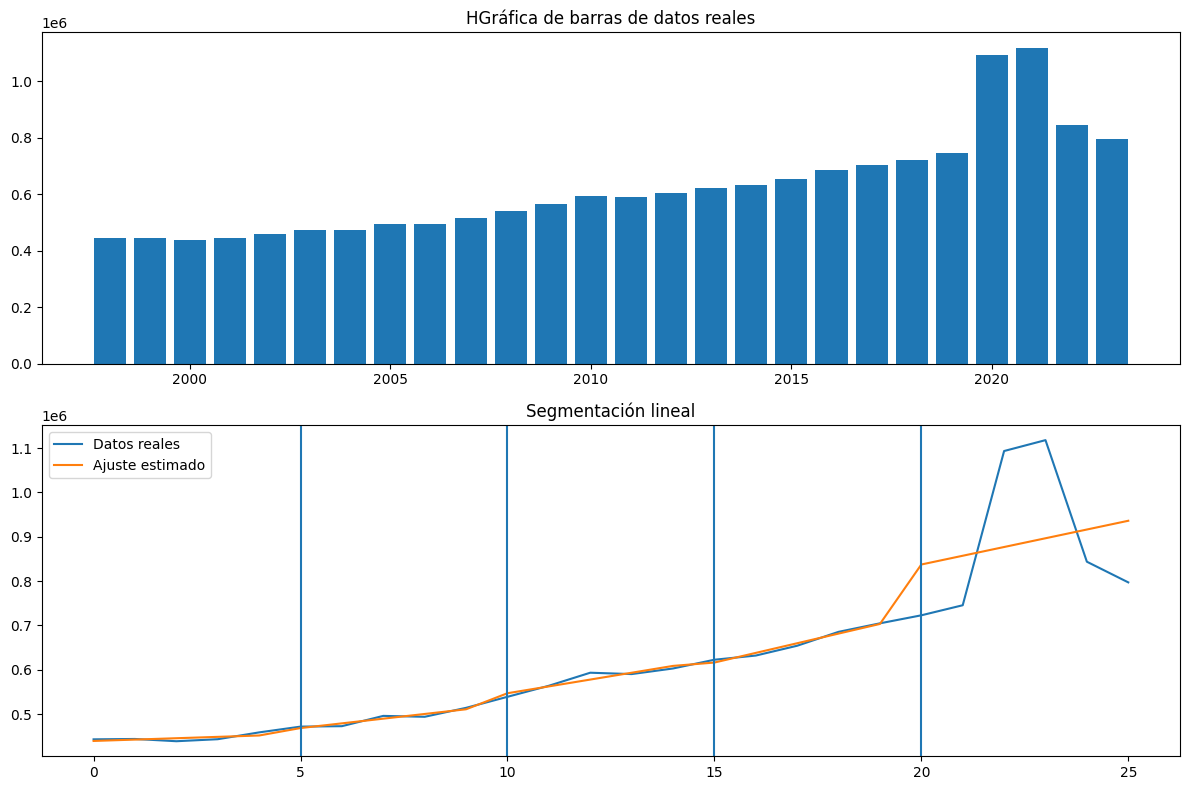

In [10]:
import numpy as np
import ruptures as rpt
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

min=1998
max=2024

# Métricas de evaluación
def r2_evaluation(bkps,y,t):
    start = 0
    y_esti = np.zeros_like(y, dtype=int)

    for end in bkps:
        t_seg = t[start:end]
        y_seg = y[start:end]

        coef = np.polyfit(t_seg, y_seg, deg=1)

        y_fit = np.polyval(coef, t_seg)

        y_esti[start:end] = y_fit
        start = end
    
    return(r2_score(y,y_esti),y_esti)

# Funciones costo
def linear_estimation(signal):
    algo = rpt.Pelt(model="linear").fit(signal)
    bkps = algo.predict(pen=10)

    return(bkps)

# Aplicación de los algoritmos de detección de puntos de cambio
conteo=(df_mortalidad_total.groupby(df_mortalidad_total["anio_ocur"].astype(int)).size().reindex(range(min, max), fill_value=0))
#print(conteo.index.tolist())   # años
#print(conteo.values.tolist())  # cantidades

anios=conteo.index.tolist()
y_real=np.array(conteo.values.tolist())
t = np.arange(len(y_real))
signal = np.column_stack((y_real, t))
bkps = linear_estimation(signal)


# Impresiones
print(bkps)
print(r2_evaluation(bkps,y_real,t)[1])
print(y_real)

y_estim=r2_evaluation(bkps,y_real,t)[1]

fig, axs = plt.subplots(2, 1, figsize=(12,8))

# Gráfica de barras
axs[0].bar(anios,y_real)
#axs[0].hist(y_real, bins=len(y_real))
axs[0].set_title("HGráfica de barras de datos reales")

# Serie temporal
axs[1].plot(t, y_real, label="Datos reales")
axs[1].plot(t, y_estim, label="Ajuste estimado")

for cp in bkps[:-1]:
    axs[1].axvline(cp)

axs[1].legend()
axs[1].set_title("Segmentación lineal")

plt.tight_layout()
plt.show()



[27]
[52448 53402 54774 55868 58140 59563 60817 62672 63260 64375 66212 67448
 69326 70388 72310 74125 77103 79475 82529 84109 85859 88482 91088 89876
 89199 91392 92945]
[50753.         52424.94871795 54096.8974359  55768.84615385
 57440.79487179 59112.74358974 60784.69230769 62456.64102564
 64128.58974359 65800.53846154 67472.48717949 69144.43589744
 70816.38461538 72488.33333333 74160.28205128 75832.23076923
 77504.17948718 79176.12820513 80848.07692308 82520.02564103
 84191.97435897 85863.92307692 87535.87179487 89207.82051282
 90879.76923077 92551.71794872 94223.66666667]


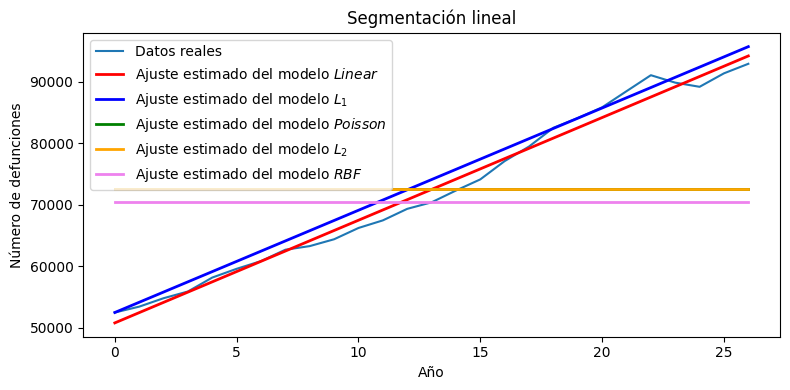

In [31]:
import numpy as np
import ruptures as rpt
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from scipy.stats import kurtosis
from scipy.stats import shapiro

anio_min=1998
anio_max=2024

################################################################ Estimaciones de y ###########################################################################
def l1_y_estimations(bkps,y_real):
    diff_y = np.diff(y_real)
    y_esti = np.zeros_like(y_real, dtype=float)
    y_esti[0] = y_real[0] 

    start = 0
    for end in bkps:
        if end > len(diff_y): end = len(diff_y)
        segment_diff = diff_y[start:end]
        if len(segment_diff) > 0:
            slope_median = np.median(segment_diff)
        else:
            slope_median = 0

        for i in range(start, end):
            y_esti[i+1] = y_esti[i] + slope_median
            
        start = end

    return (y_esti)

def poisson_y_estimations(bkps,y_real):
    y_esti = np.zeros_like(y_real, dtype=float)

    start = 0
    for end in bkps:
        segment = y_real[start:end]

        if len(segment) > 0:
            segment_mean = np.mean(segment)
            y_esti[start:end] = segment_mean

        start = end

    return (y_esti)

def normal_y_estimations(bkps,y_real):
    y_estim = np.zeros_like(y_real, dtype=float)
    start = 0
    for end in bkps:
        if len(y_real[start:end]) > 0:
            y_estim[start:end] = np.mean(y_real[start:end])
        start = end
    
    return (y_estim)

def kernel_y_estimations(bkps,y_real):
    y_estim = np.zeros_like(y_real, dtype=float)
    start = 0
    for end in bkps:
        if len(y_real[start:end]) > 0:
            y_estim[start:end] = np.median(y_real[start:end])
        start = end
    
    return(y_estim)
################################################## Métricas de evaluación y evaluaciones alternativas ########################################################
# Cálculo del coeficiente de determinación R^2
def r2_evaluation(bkps,y,t):
    start = 0
    y_esti = np.zeros_like(y, dtype=float)

    for end in bkps:
        t_seg = t[start:end]
        y_seg = y[start:end]

        if len(t_seg) > 1:
            coef = np.polyfit(t_seg, y_seg, deg=1)
            y_fit = np.polyval(coef, t_seg)
            y_esti[start:end] = y_fit
        else:
            y_esti[start:end] = y_seg
            
        start = end
    
    return(r2_score(y,y_esti),y_esti)

# Cálculo de la curtosis
def curtosis_evaluation(y_real,y_estim):
    residuos = y_real - y_estim
    curtosis = kurtosis(residuos, fisher=False)

    return (curtosis)

# Prueba de normalidad (Shapiro-Wilk)
def shapiro_wilk_test(y_real):
    p = shapiro(y_real, nan_policy='propagate')

    return (p)

# Penalización BIC con reescalamientos empíricos (lineal)
def l1_penalty(y_real):
    diff_y = np.diff(y_real)
    n_diff_y = len(diff_y)
    sigma = np.median(np.abs(diff_y)) / 0.6745
    beta = (sigma * np.log(n_diff_y)) / np.std(y_real)

    return (beta)

# Penalización BIC con reescalamientos empíricos (cuadrática)
def linear_penalty(y_real):
    diff_y = np.diff(y_real)
    n_diff_y = len(diff_y)
    sigma = np.median(np.abs(diff_y)) / 0.6745
    beta = (sigma**2 * np.log(n_diff_y)) / np.std(y_real)

    return (beta)

# Penalziación BIC_l2 
def l2_penalty(y_real):
    n = len(y_real)
    sigma = np.std(y_real)
    beta = (sigma ** 2) * np.log(n)

    return(beta)

# Penalización BIC_kernel
def kernel_penalty(y_real):
    n = len(y_real)
    cambios_absolutos = np.abs(np.diff(y_real))
    escala_robusta = np.median(cambios_absolutos) if len(cambios_absolutos) > 0 else 1.0

    if escala_robusta == 0: 
        escala_robusta = np.std(y_real) if np.std(y_real) > 0 else 1.0

    beta = escala_robusta * np.log(n)
    
    return(beta)


# Estimación de bkps con el modelo l1
def l1_smoothing(y_real, method):
    beta = l1_penalty(y_real)
    diff_y = np.diff(y_real)
    algo = CPDs(method=method,model="l1",pen=beta)
    bkps_diff = algo.fit_predict(diff_y.reshape(-1, 1))

    bkps_final = [i for i in bkps_diff]
    
    if len(y_real) not in bkps_final:
        bkps_final[-1] = len(y_real)

    return(bkps_final)

#################################### Entorno de generación de estimaciones de puntos de cambio #############################################################
class CPDs:

    def __init__(self, method, model, pen):
        self.method = method
        self.model = model
        self.pen = pen
        
        # Diccionario que contiene los métodos de busqueda
        methods_dict = {
            "Pelt": rpt.Pelt,
            "Binseg": rpt.Binseg,
            "BottomUp": rpt.BottomUp,
            "Window": rpt.Window
        }

        # En caso de emplear el método WINDOW con el modelo "l1" que no es compatible con dicho método
        if method == "Window":
            if model == "l1": model = "l2"
            if isinstance(model, str):
                self.algo = rpt.Window(width=3, model=model)
            else:
                self.algo = rpt.Window(width=3, custom_cost=model)
        else:
            if isinstance(model, str):
                self.algo = methods_dict[method](model=model, jump=1, min_size=4)
            else:
                self.algo = methods_dict[method](custom_cost=model, jump=1, min_size=4)

    def fit(self, signal):
        self.n_observations = signal.shape[0]
        self.algo.fit(signal)
        return (self)
    
    def predict(self):
        if self.method == "Pelt":
            return self.algo.predict(pen=self.pen)
        else:
            # Calculamos el límite usando división de piso (obtenemos un entero directo)
            limite_teorico = self.n_observations // 3
            
            # Reemplazamos max() y min() con condicionales puros e inmunes a la memoria
            if limite_teorico < 1:
                max_bkps = 1
            elif limite_teorico > 8:
                max_bkps = 8
            else:
                max_bkps = limite_teorico

            rss_list = []
            bkps_candidates = []

            for k in range(max_bkps + 1):
                try:
                    bkps = self.algo.predict(n_bkps=k)
                    # Calculamos el error residual usando la función de costo del modelo actual
                    rss = sum(self.algo.cost.error(start, end) for start, end in rpt.utils.pairwise(bkps))
                    
                    rss_list.append(rss)
                    bkps_candidates.append(bkps)
                except (ValueError, rpt.exceptions.NotEnoughPoints):
                    break
                except:
                    continue
                
            if len(rss_list) < 2:
                return [self.n_observations]
            
            # Método del codo matemático para encontrar el número óptimo de cortes
            rss_arr = np.array(rss_list)
            n_puntos = len(rss_arr)
            linea_base = np.linspace(rss_arr[0], rss_arr[-1], n_puntos)
            distancias = linea_base - rss_arr
            idx_optimo = np.argmax(distancias)
            
            return bkps_candidates[idx_optimo]
            

    def fit_predict(self,signal):
        self.fit(signal)
        return self.predict()
    
class PoissonCostFunction:
    model = "Poisson"
    min_size = 2

    def fit(self, signal):
        self.signal = signal.astype(float)
        return self
    
    def error(self, start, end):
        sub = self.signal[start:end]
        n = end - start 
        if n <= 0: return 0

        mean_seg = np.mean(sub)
        # Caso donde la media sea 0 y asi evitar log(0) o la media sea menor a 0 y log() sea muy negativo
        if mean_seg <= 0: return 0

        return (-(n * mean_seg * np.log(mean_seg)))

################################################ Captura de datos reales y pasos iniciales ######################################################################
# EDITAR
#conteo = (df_mortalidad_total.groupby(df_mortalidad_total["ANIO_OCUR"].astype(int)).size().reindex(range(anio_min, anio_max+1), fill_value=0)) # Selección de datos
conteo = (df_mortalidad_total[(df_mortalidad_total['CAUSA_DEF'].between('C000', 'C979')) & (df_mortalidad_total['ANIO_OCUR'].astype(int)>=1998) & (df_mortalidad_total['ANIO_OCUR'].astype(int)<2025)].groupby('ANIO_OCUR').size())
method = "BottomUp" # Selección de método de búsqueda

# NO EDITAR
anios = conteo.index.tolist()
y_real = np.array(conteo.values.tolist())
t = np.arange(len(y_real))
signal = y_real.reshape(-1, 1)

# Calculamos el parámetro de penalización beta (Penalización BIC normalizada)
beta = linear_penalty(y_real)
detect = CPDs(method=method,model="linear",pen=beta)
bkps = detect.fit_predict(signal)

################################################### Elección del modelo de detección ###################################################################################
r2_value, y_estim = r2_evaluation(bkps,y_real,t)
curtosis = curtosis_evaluation(y_real,y_estim)
# L1
bkps2 = l1_smoothing(y_real,method)
y_estim2 = l1_y_estimations(bkps2,y_real)
# POISSON
beta_poisson = np.mean(y_real) * np.log(len(y_real))
poisson_detect = CPDs(method, PoissonCostFunction(), beta_poisson)
bkps3 = poisson_detect.fit_predict(y_real.reshape(-1,1))
y_estim3 = poisson_y_estimations(bkps3,y_real)
# GAUSSIAN
normal_detect = CPDs(method=method,model="l2",pen=l2_penalty(y_real))
bkps4 = normal_detect.fit_predict(y_real.reshape(-1,1))
y_estim4 = normal_y_estimations(bkps4,y_real)
# KERNEL(rbf)
kernel_detect = CPDs(method=method,model="rbf",pen=kernel_penalty(y_real))
signal_k = y_real.reshape(-1, 1)
bkps5 = kernel_detect.fit_predict(signal_k)
y_estim5 = kernel_y_estimations(bkps5,y_real)

#fig, axs = plt.subplots(1, 1, figsize=(12,8))
fig, axs = plt.subplots(1, 1, figsize=(8,4))

print(bkps)
print(y_real)
print(y_estim)

# Gráfica de barras (permanece igual de inicio a fin)
#axs.bar(anios,y_real)
#axs.set_title("Gráfica de barras de datos reales")
#axs[0].bar(anios,y_real)
#axs[0].set_title("Gráfica de barras de datos reales")

# Serie temporal (Cambia según la elección )
axs.plot(t, y_real, label="Datos reales")
axs.plot(t, y_estim, label=r'Ajuste estimado del modelo $\mathit{Linear}$',color="red",linewidth=2)
axs.plot(t, y_estim2, label=f'Ajuste estimado del modelo $L_1$',color="blue",linewidth=2)
axs.plot(t, y_estim3, label=r'Ajuste estimado del modelo $\mathit{Poisson}$',color="green",linewidth=2)
axs.plot(t, y_estim4, label=f'Ajuste estimado del modelo $L_2$',color="orange",linewidth=2)
axs.plot(t, y_estim5, label=r'Ajuste estimado del modelo $\mathit{RBF}$',color="violet",linewidth=2)
#axs[1].plot(t, y_real, label="Datos reales")
#axs[1].plot(t, y_estim, label="Ajuste estimado")

#for cp in bkps[:-1]:
#    axs.axvline(cp)
    #axs[1].axvline(cp)

for cp in bkps[:-1]:
    axs.axvline(cp, color='red', linestyle='--', linewidth=1)

for cp in bkps2[:-1]:
    axs.axvline(cp, color='blue', linestyle=':', linewidth=1)

for cp in bkps3[:-1]:
    axs.axvline(cp, color='green', linestyle='-.', linewidth=1)

for cp in bkps4[:-1]:
    axs.axvline(cp, color='orange', linestyle='-', linewidth=1)

for cp in bkps5[:-1]:
    axs.axvline(cp, color='violet', linestyle='--', linewidth=1)

axs.legend()
axs.set_title("Segmentación lineal")
#axs[1].legend()
#axs[1].set_title("Segmentación lineal")

plt.xlabel("Año")
plt.ylabel("Número de defunciones")
plt.tight_layout()
plt.show()

ARIMA

Test ADF para verificar estacionariedad

In [ ]:
from statsmodels.tsa.stattools import adfuller

train_count = (df_mortalidad_total.groupby(df_mortalidad_total["ANIO_OCUR"].astype(int)).size().reindex(range(1998, 2022), fill_value=0))
test_count = (df_mortalidad_total.groupby(df_mortalidad_total["ANIO_OCUR"].astype(int)).size().reindex(range(2022, 2025), fill_value=0))
#train_count = (df_mortalidad_total[(df_mortalidad_total['CAUSA_DEF'].between('C000', 'C979')) & (df_mortalidad_total['ANIO_OCUR'].astype(int)>=1998) & (df_mortalidad_total['ANIO_OCUR'].astype(int)<2022)].groupby('ANIO_OCUR').size())
#test_count = (df_mortalidad_total[(df_mortalidad_total['CAUSA_DEF'].between('C000', 'C979')) & (df_mortalidad_total['ANIO_OCUR'].astype(int)>=2022) & (df_mortalidad_total['ANIO_OCUR'].astype(int)<2025)].groupby('ANIO_OCUR').size())
# Conjunto prueba
y_prueba = np.array(test_count.values)

# Conjunto entrenamiento
y_original = np.array(train_count.values)
y_diferenciada = np.array(train_count.diff().dropna().tolist())  # Aplicación de una n-ésima diferencia regular

adf_test = adfuller(y_diferenciada)
print(adf_test[0])
print(adf_test[1])

-4.443081493977835
0.00024884022248445714


Verificación de parámetros p y q

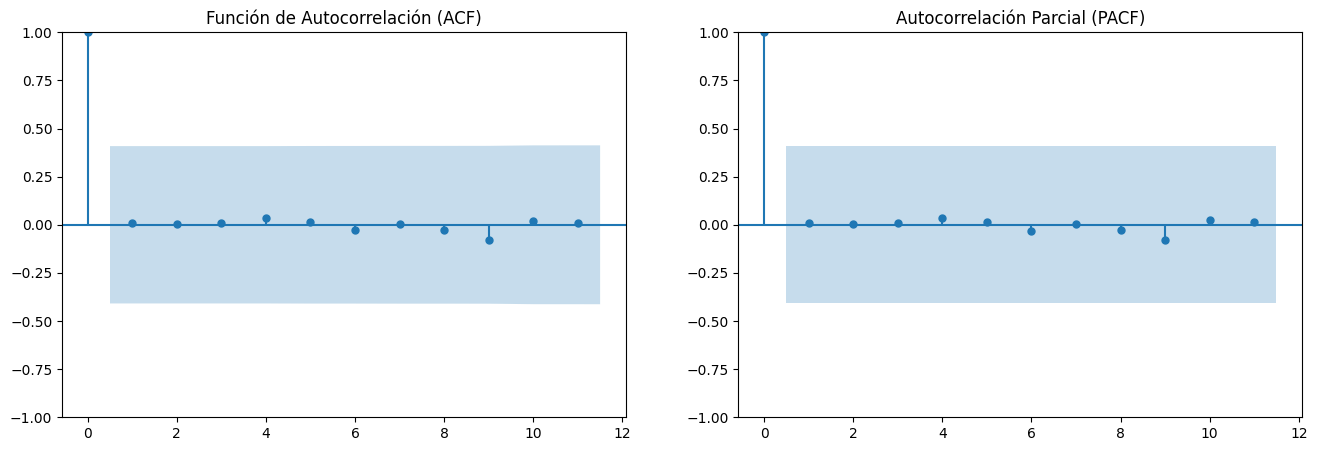

In [174]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(y_diferenciada, ax=axes[0], title='Función de Autocorrelación (ACF)')

plot_pacf(y_diferenciada, ax=axes[1], title='Autocorrelación Parcial (PACF)')

plt.show()

Construcción, entrenamiento y predicción con el modelo ARIMA

In [185]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(y_original, order=(0,1,0), trend='t') # NOTA: Se ajusto la tendencia dado que se trataba de un caso (0,1,0)
model_fit = model.fit()

# Aplicamos forecasting a steps=x (según la unidad temporal empleada)
forecast = model_fit.get_forecast(steps=3) 

# Extraemos la predicción puntual y los intervalos al 95% de confianza
predicciones = forecast.predicted_mean
intervalos = forecast.conf_int(alpha=0.05) 
limite_inferior = intervalos[:, 0]
limite_superior = intervalos[:, 1]

# Definimos el arreglo de observaciones temporales conocidas y observaciones temporales predichas
serie_conocida = np.arange(1998,2022)
serie_predicha = np.arange(2022,2025) 

ajuste_historico = model_fit.fittedvalues

Gráfica de predicciones

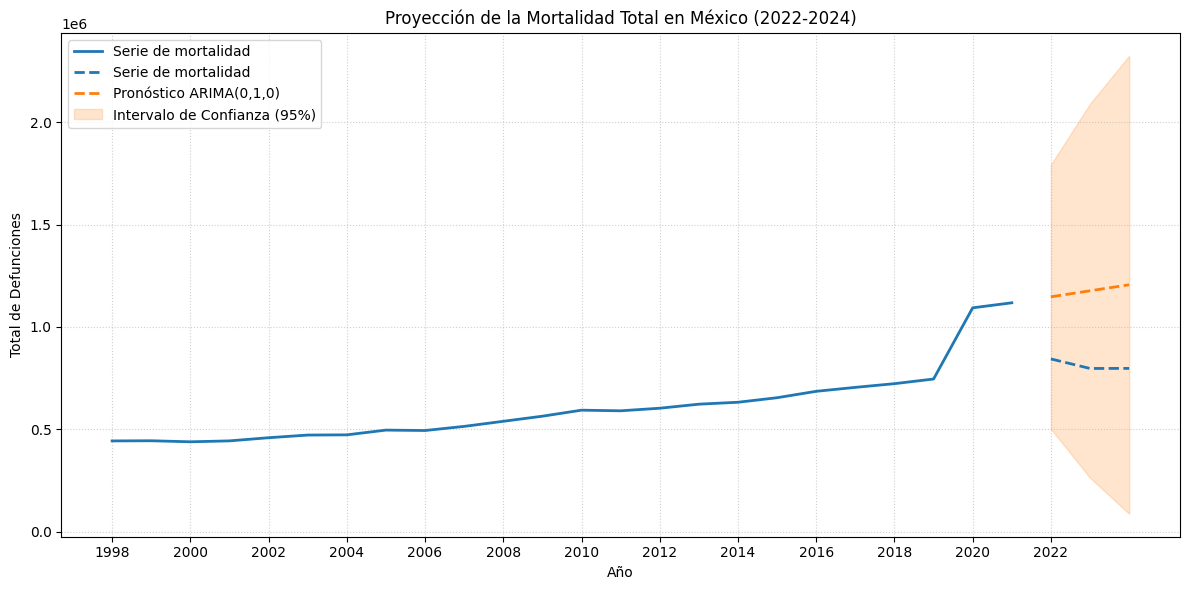

In [182]:
plt.figure(figsize=(12, 6))

# Graficamos la serie original
plt.plot(serie_conocida, y_original, label='Serie de mortalidad', color='#1f77b4', linewidth=2)
plt.plot(serie_predicha, y_prueba, label='Serie de mortalidad', color='#1f77b4', linewidth=2, linestyle='--')

# Graficamos la serie predicha
plt.plot(serie_predicha, predicciones, label='Pronóstico ARIMA(0,1,0)', color='#ff7f0e', linestyle='--', linewidth=2)

# Dibujamos el intervalo de confianza
plt.fill_between(serie_predicha, limite_inferior, limite_superior, color='#ff7f0e', alpha=0.2, label='Intervalo de Confianza (95%)')

# Formato estético
plt.title('Proyección de la Mortalidad Total en México (2022-2024)')
plt.xlabel('Año')
plt.ylabel('Total de Defunciones')
plt.xticks(np.arange(1998, 2024, 2)) # Saltos de 2 en 2 años para que se vea limpio
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Redes neuronales

Escalamiento de los datos

In [280]:
from sklearn.preprocessing import MinMaxScaler

#train_count = (df_mortalidad_total.groupby(df_mortalidad_total["ANIO_OCUR"].astype(int)).size().reindex(range(1998, 2025), fill_value=0))
train_count = (df_mortalidad_total[(df_mortalidad_total['CAUSA_DEF'].between('C000', 'C979')) & (df_mortalidad_total['ANIO_OCUR'].astype(int)>=1998) & (df_mortalidad_total['ANIO_OCUR'].astype(int)<2025)].groupby('ANIO_OCUR').size())

# Conjunto entrenamiento
y_original = np.array(train_count.values)

# Transposición de los datos originales
y_transpuesto = y_original.reshape(-1, 1)

# Definimos el escalador
escalador = MinMaxScaler(feature_range=(0, 1))

# Aplicamos la compresión de los datos originales sobre el rango definido en el escalador
y_escalado = escalador.fit_transform(y_transpuesto)



Creación de las ventanas deslizantes

In [281]:
import tensorflow as tf
import math

# Definimos el número de "pasos" que se desea predecir
steps = 3

# Numero total de ventanas
N = len(y_escalado) - steps + 1

# Error emergente en caso de pasarse del tamaño de ventana permitido por la longitud de la muestra
if N <= 0:
        raise ValueError("La muestra es demasiado corta para esa secuencia.")

objetivo = math.sqrt(N)

potencia = max(0, int(math.log2(objetivo)))
batch_size = 2 ** potencia
batch_size = min(batch_size, 512)

# Creamos el generador de ventanas deslizantes nativo
dataset_tf = tf.keras.utils.timeseries_dataset_from_array(
    data=y_escalado[:-steps],    # Los predictores 
    targets=y_escalado[steps:],  # El futuro
    sequence_length=steps,       # El tamaño de la ventana 
    batch_size=batch_size               # Numero de ventanas procesadas a la vez
)



Partición cronológica del conjunto de datos

In [282]:
import numpy as np

def crear_secuencias(datos, tamaño_ventana):
    X_seq, Y_seq = [], []
    for i in range(len(datos) - tamaño_ventana):
        X_seq.append(datos[i:(i + tamaño_ventana), 0])
        Y_seq.append(datos[i + tamaño_ventana, 0])
    return np.array(X_seq), np.array(Y_seq)

# Definimos las matrices base
X,Y = crear_secuencias(y_escalado, steps)

# Reestructuramos el tensor
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Indice donde caera el corte
indice_corte = len(X) - steps

# Definimos el conjunto de entrenamiento (Desde el inicio hasta el corte)
X_train = X[:indice_corte]
Y_train = Y[:indice_corte]

# Definimos el conjunto de prueba (Desde el corte hasta el final)
X_test = X[indice_corte:]
Y_test = Y[indice_corte:]

print("=== Dimensiones de Entrenamiento ===")
print(f"X_train: {X_train.shape} (Muestras, Pasos_historia, Características)")
print(f"Y_train: {Y_train.shape} (Muestras objetivo)\n")

print("=== Dimensiones de Prueba ===")
print(f"X_test: {X_test.shape} (Muestras, Pasos_historia, Características)")
print(f"Y_test: {Y_test.shape} (Muestras objetivo)")



=== Dimensiones de Entrenamiento ===
X_train: (21, 3, 1) (Muestras, Pasos_historia, Características)
Y_train: (21,) (Muestras objetivo)

=== Dimensiones de Prueba ===
X_test: (3, 3, 1) (Muestras, Pasos_historia, Características)
Y_test: (3,) (Muestras objetivo)


Diseño de la arquitectura RNN de tipo LSTM

In [283]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Instanciamos la red neuronal
modelo_lstm = Sequential()

# Definimos la cantidad de neuronas
Nh = math.floor( N / (2 * (steps + 1)))

# Definimos la regla de regularizacion
r = 0.1

# Definimos la primera capa con Nh neuronas de memoria, definimos la forma de la entrada de los datos y confirmamos la conexion para una LSTM posterior
modelo_lstm.add(LSTM(units=Nh, return_sequences=True, input_shape=(X_train.shape[1], 1)))

# Definimos la capa de regularizacion (para lidiar con el sobreajuste), apagando un porcentaje de ([0,1])*100 de las neuronas al azar en cada iteracion
modelo_lstm.add(Dropout(r))

# Definimos la segunda capa con Nh neuronas apagando el mismo porcentaje de neuronas por iteracion y, regresando la informacion en un vector final
modelo_lstm.add(LSTM(units=Nh, return_sequences=False))
modelo_lstm.add(Dropout(r))

# Definimos la capa de salida con una sola salida, correspondiente a la prediccion del año siguiente.
modelo_lstm.add(Dense(units=1))

# Determinamos el algoritmo que ajustara los pesos y la metrica de error la cual la red intentara destruir
modelo_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Imprimimos la radiografia del modelo
modelo_lstm.summary()

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 3, 3)           │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 3, 3)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 3)              │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148 (592.00 B)

 Trainable params: 148 (592.00 B)

 Non-trainable params: 0 (0.00 B)

Entrenamiento y gráfica basada de la función de perdida

Epoch 1/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.3519 - val_loss: 1.0043
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3391 - val_loss: 0.9676
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3211 - val_loss: 0.9336
Epoch 4/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3045 - val_loss: 0.9011
Epoch 5/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2906 - val_loss: 0.8700
Epoch 6/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2724 - val_loss: 0.8392
Epoch 7/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2629 - val_loss: 0.8080
Epoch 8/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2447 - val_loss: 0.7774
Epoch 9/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2351 - val_loss: 0.7472
Epoch 10/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2199 - val_loss: 0.7194
Epoch 11/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2116 - val_loss: 0.6919
Epoch 12/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2018 - val_lo

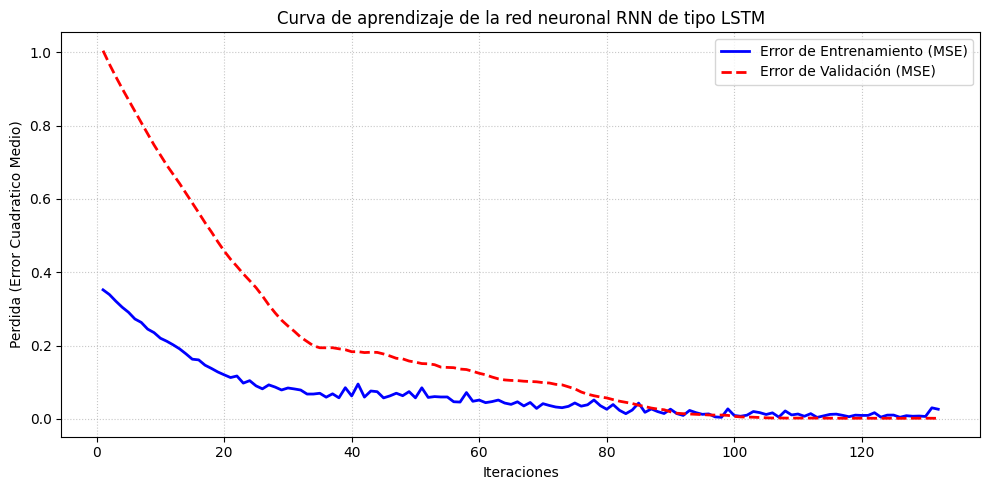

In [284]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

parada_temprana = EarlyStopping(monitor='val_loss', patience=5)

# Definimos la variable que registrara todo el proceso para graficarlo despues
historial = modelo_lstm.fit(
    X_train, Y_train,
    epochs=150,           # Numero de repeticiones que hara la red sobre la historia
    batch_size=batch_size,         # Se actualizara cada ''batch_size'' ventanas leidas (definido con anterioridad)
    validation_data=(X_test, Y_test), # Le pasamos las observaciones siguientes para poder observar su seguimiento
    verbose=1,             # Se muestra una barra de progreso en la consola
    callbacks=[parada_temprana]
)

# Graficamos la curva de aprendizaje (basada en la funcion de perdida)
plt.figure(figsize=(10, 5))

# Extraer los errores de la fase de estudio y la fase de examen
error_entrenamiento = historial.history['loss']
error_validacion = historial.history['val_loss']
epocas = range(1, len(error_entrenamiento) + 1)

# Dibujar las líneas
plt.plot(epocas, error_entrenamiento, 'b-', label='Error de Entrenamiento (MSE)', linewidth=2)
plt.plot(epocas, error_validacion, 'r--', label='Error de Validación (MSE)', linewidth=2)

# Formato estético
plt.title('Curva de aprendizaje de la red neuronal RNN de tipo LSTM')
plt.xlabel('Iteraciones')
plt.ylabel('Perdida (Error Cuadratico Medio)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Registro de las predicciones, la escala inversa y la metrica de error

In [285]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Definimos el arreglo de predicciones solicitado a la red mediante X_test
predicciones_escaladas = modelo_lstm.predict(X_test)

# Deshacemos la compresion inicial sobre el arreglo de predicciones
predicciones_reales = escalador.inverse_transform(predicciones_escaladas)

y_test_real = escalador.inverse_transform(Y_test.reshape(-1, 1))

# Calculamos el Error Cuadrático Medio (MSE) y le sacamos la raíz (RMSE)
rmse_lstm = np.sqrt(mean_squared_error(y_test_real, predicciones_reales))

print(f"=== RESULTADOS DEL EXAMEN FINAL ===")
print(f"Predicciones de la red: \n{predicciones_reales.flatten()}")
print(f"Valores reales observados: \n{y_test_real.flatten()}")
print(f"\nERROR RMSE: {rmse_lstm:,.2f} defunciones de diferencia promedio")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
=== RESULTADOS DEL EXAMEN FINAL ===
Predicciones de la red: 
[91269.945 91878.52  91513.06 ]
Valores reales observados: 
[89199. 91392. 92945.]

ERROR RMSE: 1,480.54 defunciones de diferencia promedio


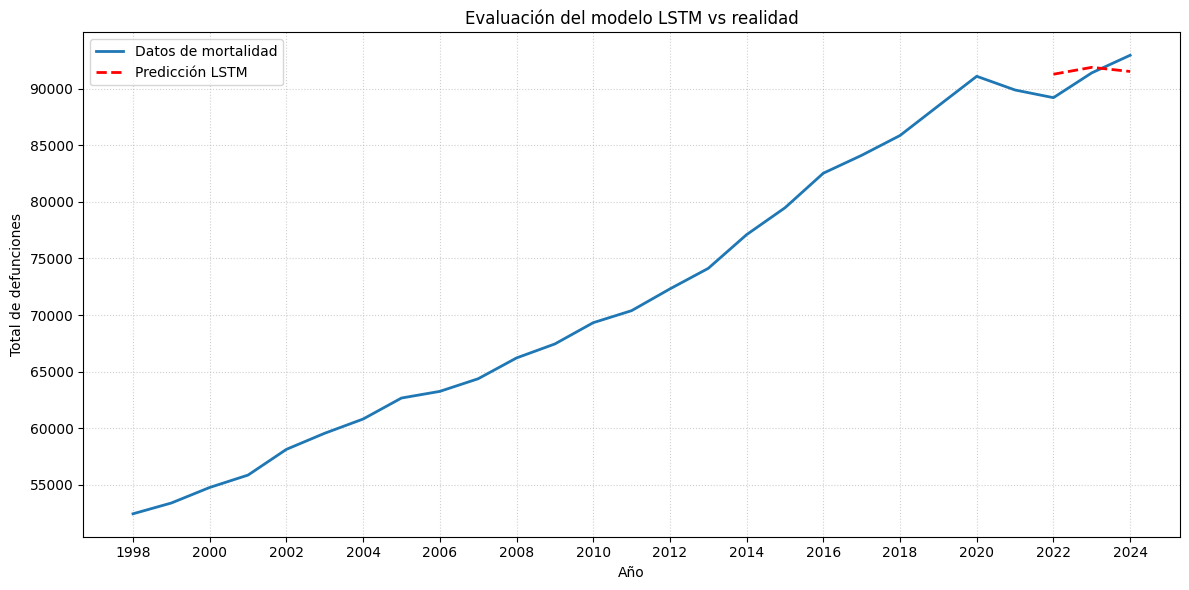

In [286]:
plt.figure(figsize=(12, 6))

# Años para la gráfica 
años_totales = np.arange(1998, 2025)
años_prueba = años_totales[-steps:] # Extrae los últimos 3 años

# Dibujamos toda la historia real en azul
plt.plot(años_totales, y_original, label='Datos de mortalidad', color='#1f77b4', linewidth=2)

# Empalmamos las predicciones de la red neuronal en rojo punteado
plt.plot(años_prueba, predicciones_reales, label='Predicción LSTM', color='red', linestyle='--', linewidth=2)

# Formato estético
plt.title('Evaluación del modelo LSTM vs realidad')
plt.xlabel('Año')
plt.ylabel('Total de defunciones')
plt.xticks(np.arange(1998, 2026, 2))
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()